# Chapter 11 Teaching Notebook: Maritime Traffic Flow Prediction with Graph WaveNet

This notebook demonstrates how to train and evaluate a graph-based deep learning model for maritime traffic flow prediction. The traffic area is represented as a graph, where each node corresponds to a clustered traffic region and weighted edges describe spatial or transition relationships between nodes.

The workflow includes data loading, graph normalization, feature normalization, model construction, training, test evaluation, and map-based visualization of predicted node flow.

**Note.** The code logic, training procedure, model structure, and output settings are kept unchanged. Only teaching Markdown explanations and a few explanatory comments have been added, and repeated imports have been removed from the visualization cell.

## 1. Graph WaveNet Training Pipeline

This section trains a Graph WaveNet model for short-term maritime traffic flow prediction. The model uses previous graph states as input and predicts the future vessel-flow count at each traffic node. The adjacency matrix is normalized and used as the graph support for graph convolution.

In [1]:
# ============================================================
# Cell: Graph WaveNet training for graph-based maritime traffic flow prediction
# Data: clustered traffic nodes, 2h interval, K=18
# Task: use previous P graph states to predict future node flow
# ============================================================

import os
import json
import time
import random
import numpy as np
import pandas as pd

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

# ============================================================
# 1) Basic settings
# ============================================================

DATA_PATH = "GNN_flow_data/korea_strait_graph_flow_2021_k18_2h.npz"

RUN_DIR = "Graph_WaveNet"
os.makedirs(RUN_DIR, exist_ok=True)

LOG_PATH = os.path.join(RUN_DIR, "training_log.csv")
BEST_MODEL_PATH = os.path.join(RUN_DIR, "best_model.pth")
FINAL_MODEL_PATH = os.path.join(RUN_DIR, "final_model.pth")
CONFIG_PATH = os.path.join(RUN_DIR, "config.json")
TEST_METRICS_PATH = os.path.join(RUN_DIR, "test_metrics.json")

# Input and output setting
P = 6       # previous 6 time steps = previous 12 hours
Q = 1       # predict next 1 time step = next 2 hours

# Training setting
BATCH_SIZE = 64
EPOCHS = 200
LR = 1e-3
WEIGHT_DECAY = 1e-5
GRAD_CLIP = 1.0

# Model setting
HIDDEN_DIM = 64
DROPOUT = 0.10
KERNEL_SIZE = 3
DILATIONS = [1, 2, 4]
ADAPTIVE_EMB_DIM = 10

# Loss setting
POS_WEIGHT = 2.0       # extra weight for non-zero target nodes
LAMBDA_MAE = 0.5       # add MAE term to stabilize count prediction

# Evaluation setting
OCC_THRESHOLD = 0.5    # predicted count >= 0.5 means occupied node

# Reproducibility
SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

# ============================================================
# 2) Load graph flow data
# ============================================================

# The .npz file stores graph signals, target flows, graph structure, and data splits.
data = np.load(DATA_PATH, allow_pickle=True)

X_node = data["X_node"].astype(np.float32)     # [samples, P, N, F]
Y_node = data["Y_node"].astype(np.float32)     # [samples, Q, N, 1]

A = data["A_sym_weighted"].astype(np.float32)  # [N, N], weighted node adjacency matrix
train_idx = data["train_idx"].astype(int)
val_idx = data["val_idx"].astype(int)
test_idx = data["test_idx"].astype(int)

time_index = data["time_index"]
node_center_lat = data["node_center_lat"]
node_center_lng = data["node_center_lng"]

num_samples, P_data, N, F_in = X_node.shape
_, Q_data, N_y, F_y = Y_node.shape

assert P_data == P, f"P in data is {P_data}, but P setting is {P}"
assert Q_data == Q, f"Q in data is {Q_data}, but Q setting is {Q}"
assert N == N_y, "Node number mismatch"

print("Loaded data:", DATA_PATH)
print("X_node shape:", X_node.shape)
print("Y_node shape:", Y_node.shape)
print("Adjacency shape:", A.shape)
print("Train samples:", len(train_idx))
print("Val samples:", len(val_idx))
print("Test samples:", len(test_idx))

print("\nTarget statistics:")
print("Y max:", float(Y_node.max()))
print("Y non-zero ratio:", float(np.count_nonzero(Y_node) / Y_node.size))
print("Y mean:", float(Y_node.mean()))

# ============================================================
# 3) Normalize adjacency matrix
# ============================================================

def normalize_adjacency(A):
    """
    Symmetric normalization: A_hat = D^{-1/2} (A + I) D^{-1/2}
    """
    A = A.copy()
    N = A.shape[0]

    A = A + np.eye(N, dtype=np.float32)

    degree = A.sum(axis=1)
    degree_inv_sqrt = np.power(degree + 1e-8, -0.5)
    D_inv_sqrt = np.diag(degree_inv_sqrt)

    A_norm = D_inv_sqrt @ A @ D_inv_sqrt

    return A_norm.astype(np.float32)

# Convert the normalized graph structure into a tensor used by graph convolution.
A_norm = normalize_adjacency(A)
A_tensor = torch.from_numpy(A_norm).float().to(device)

print("\nNormalized adjacency matrix:")
print("A_norm shape:", A_norm.shape)
print("A_norm min:", float(A_norm.min()))
print("A_norm max:", float(A_norm.max()))

# ============================================================
# 4) Normalization for node features and target
# ============================================================

# Feature-wise scaling based only on training samples
x_scale = X_node[train_idx].reshape(-1, F_in).max(axis=0)
x_scale = np.maximum(x_scale, 1.0).astype(np.float32)

# Target scaling based only on training samples
y_scale = float(Y_node[train_idx].max())
y_scale = max(y_scale, 1.0)

print("\nScaling:")
print("x_scale:", x_scale)
print("y_scale:", y_scale)

# ============================================================
# 5) Dataset and DataLoader
# ============================================================

class GraphTrafficDataset(Dataset):
    def __init__(self, X_node, Y_node, indices, x_scale, y_scale):
        self.X_node = X_node
        self.Y_node = Y_node
        self.indices = indices
        self.x_scale = x_scale.reshape(1, 1, -1)
        self.y_scale = y_scale

    def __len__(self):
        return len(self.indices)

    def __getitem__(self, idx):
        s = self.indices[idx]

        x = self.X_node[s] / self.x_scale      # [P, N, F]
        y = self.Y_node[s] / self.y_scale      # [Q, N, 1]

        x = torch.from_numpy(x).float()
        y = torch.from_numpy(y).float()

        return x, y


train_dataset = GraphTrafficDataset(X_node, Y_node, train_idx, x_scale, y_scale)
val_dataset = GraphTrafficDataset(X_node, Y_node, val_idx, x_scale, y_scale)
test_dataset = GraphTrafficDataset(X_node, Y_node, test_idx, x_scale, y_scale)

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=0,
    pin_memory=True if device.type == "cuda" else False
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=0,
    pin_memory=True if device.type == "cuda" else False
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=0,
    pin_memory=True if device.type == "cuda" else False
)

# ============================================================
# 6) Graph WaveNet model
# ============================================================

class GraphWaveNetGraphConv(nn.Module):
    """
    Graph convolution used in Graph WaveNet.

    Input:
        x: [B, C, N, T]
        supports: list of [N, N]

    Output:
        out: [B, C_out, N, T]
    """
    def __init__(self, in_channels, out_channels, support_len, dropout=0.1):
        super().__init__()

        self.mlp = nn.Conv2d(
            in_channels * (support_len + 1),
            out_channels,
            kernel_size=(1, 1)
        )

        self.dropout = nn.Dropout(dropout)

    def forward(self, x, supports):
        out = [x]

        for A in supports:
            x_g = torch.einsum("ij,bcjt->bcit", A, x)
            out.append(x_g)

        out = torch.cat(out, dim=1)
        out = self.mlp(out)
        out = self.dropout(out)

        return out


class GraphWaveNetBlock(nn.Module):
    """
    Graph WaveNet block:
        dilated causal temporal convolution + graph convolution + residual connection
    """
    def __init__(
        self,
        channels,
        kernel_size,
        dilation,
        support_len,
        dropout=0.1
    ):
        super().__init__()

        self.kernel_size = kernel_size
        self.dilation = dilation
        self.padding = dilation * (kernel_size - 1)

        self.filter_conv = nn.Conv2d(
            channels,
            channels,
            kernel_size=(1, kernel_size),
            dilation=(1, dilation)
        )

        self.gate_conv = nn.Conv2d(
            channels,
            channels,
            kernel_size=(1, kernel_size),
            dilation=(1, dilation)
        )

        self.graph_conv = GraphWaveNetGraphConv(
            in_channels=channels,
            out_channels=channels,
            support_len=support_len,
            dropout=dropout
        )

        self.residual_conv = nn.Conv2d(
            channels,
            channels,
            kernel_size=(1, 1)
        )

        self.bn = nn.BatchNorm2d(channels)
        self.dropout = nn.Dropout(dropout)

    def forward(self, x, supports):
        # x: [B, C, N, T]

        residual = x

        # Causal padding on temporal dimension
        x_pad = F.pad(x, (self.padding, 0, 0, 0))

        filter_out = torch.tanh(self.filter_conv(x_pad))
        gate_out = torch.sigmoid(self.gate_conv(x_pad))

        out = filter_out * gate_out
        out = self.dropout(out)

        out = self.graph_conv(out, supports)
        out = self.residual_conv(out)

        out = out + residual
        out = self.bn(out)

        return out


class GraphWaveNetModel(nn.Module):
    """
    Graph WaveNet for node-level maritime traffic flow prediction.

    Input:
        x: [B, P, N, F]

    Output:
        y_hat: [B, Q, N, 1]
    """
    def __init__(
        self,
        input_dim,
        hidden_dim,
        num_nodes,
        output_dim=1,
        q=1,
        kernel_size=3,
        dilations=None,
        adaptive_emb_dim=10,
        dropout=0.1
    ):
        super().__init__()

        if dilations is None:
            dilations = [1, 2, 4]

        self.num_nodes = num_nodes
        self.hidden_dim = hidden_dim
        self.output_dim = output_dim
        self.q = q
        self.dilations = dilations

        self.start_conv = nn.Conv2d(
            input_dim,
            hidden_dim,
            kernel_size=(1, 1)
        )

        # Adaptive adjacency matrix
        self.nodevec1 = nn.Parameter(
            torch.randn(num_nodes, adaptive_emb_dim),
            requires_grad=True
        )

        self.nodevec2 = nn.Parameter(
            torch.randn(adaptive_emb_dim, num_nodes),
            requires_grad=True
        )

        support_len = 2   # predefined adjacency + adaptive adjacency

        self.blocks = nn.ModuleList([
            GraphWaveNetBlock(
                channels=hidden_dim,
                kernel_size=kernel_size,
                dilation=d,
                support_len=support_len,
                dropout=dropout
            )
            for d in dilations
        ])

        self.decoder = nn.Sequential(
            nn.Linear(hidden_dim, hidden_dim),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim, q * output_dim)
        )

        # Initialize final layer bias to avoid too-large initial predictions
        nn.init.constant_(self.decoder[-1].bias, -2.0)

    def forward(self, x, A_norm):
        # x: [B, P, N, F]

        # [B, P, N, F] -> [B, F, N, P]
        x = x.permute(0, 3, 2, 1)

        # Initial projection
        x = self.start_conv(x)                 # [B, H, N, P]

        # Adaptive adjacency
        A_adp = F.softmax(
            F.relu(torch.mm(self.nodevec1, self.nodevec2)),
            dim=1
        )

        supports = [A_norm, A_adp]

        for block in self.blocks:
            x = block(x, supports)

        # Use the last temporal state
        h = x[:, :, :, -1]                     # [B, H, N]
        h = h.permute(0, 2, 1)                 # [B, N, H]

        out = self.decoder(h)                  # [B, N, Q]
        out = out.view(out.shape[0], out.shape[1], self.q, self.output_dim)
        out = out.permute(0, 2, 1, 3)           # [B, Q, N, 1]

        # Non-negative count prediction
        out = F.softplus(out)

        return out


model = GraphWaveNetModel(
    input_dim=F_in,
    hidden_dim=HIDDEN_DIM,
    num_nodes=N,
    output_dim=1,
    q=Q,
    kernel_size=KERNEL_SIZE,
    dilations=DILATIONS,
    adaptive_emb_dim=ADAPTIVE_EMB_DIM,
    dropout=DROPOUT
).to(device)

num_params = sum(p.numel() for p in model.parameters() if p.requires_grad)

print("\nModel:", model.__class__.__name__)
print("Trainable parameters:", num_params)

# ============================================================
# 7) Loss function and metrics
# ============================================================

class WeightedCountLoss(nn.Module):
    """
    Weighted MSE + MAE.
    Non-zero target nodes receive larger weights.
    """
    def __init__(self, pos_weight=2.0, lambda_mae=0.5):
        super().__init__()

        self.pos_weight = pos_weight
        self.lambda_mae = lambda_mae

    def forward(self, pred, target):
        weight = 1.0 + self.pos_weight * (target > 0).float()

        mse = (weight * (pred - target) ** 2).mean()
        mae = (weight * torch.abs(pred - target)).mean()

        loss = mse + self.lambda_mae * mae

        return loss, {
            "mse": mse.detach(),
            "mae_loss": mae.detach()
        }


criterion = WeightedCountLoss(
    pos_weight=POS_WEIGHT,
    lambda_mae=LAMBDA_MAE
)

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=LR,
    weight_decay=WEIGHT_DECAY
)

scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode="min",
    factor=0.5,
    patience=8,
    min_lr=1e-6
)


@torch.no_grad()
def evaluate(model, loader, criterion, A_tensor, y_scale, device, occ_threshold=0.5):
    model.eval()

    total_loss = 0.0
    total_mse_loss = 0.0
    total_mae_loss = 0.0
    total_batches = 0

    abs_sum = 0.0
    sq_sum = 0.0
    num_elements = 0

    abs_sum_nz = 0.0
    sq_sum_nz = 0.0
    ape_sum_nz = 0.0
    num_nz = 0

    total_true_sum = 0.0
    total_pred_sum = 0.0

    tp = 0.0
    fp = 0.0
    fn = 0.0
    tn = 0.0

    all_true = []
    all_pred = []

    for x_batch, y_batch in loader:
        x_batch = x_batch.to(device)
        y_batch = y_batch.to(device)

        pred = model(x_batch, A_tensor)

        loss, loss_parts = criterion(pred, y_batch)

        total_loss += loss.item()
        total_mse_loss += loss_parts["mse"].item()
        total_mae_loss += loss_parts["mae_loss"].item()
        total_batches += 1

        # Convert back to original count scale
        pred_ori = pred * y_scale
        y_ori = y_batch * y_scale

        diff = pred_ori - y_ori
        abs_diff = torch.abs(diff)
        sq_diff = diff ** 2

        abs_sum += abs_diff.sum().item()
        sq_sum += sq_diff.sum().item()
        num_elements += y_ori.numel()

        mask = y_ori > 0

        if mask.sum().item() > 0:
            abs_sum_nz += abs_diff[mask].sum().item()
            sq_sum_nz += sq_diff[mask].sum().item()
            ape_sum_nz += (abs_diff[mask] / (y_ori[mask] + 1e-6)).sum().item()
            num_nz += mask.sum().item()

        total_true_sum += y_ori.sum().item()
        total_pred_sum += pred_ori.sum().item()

        occ_true = y_ori > 0
        occ_pred = pred_ori >= occ_threshold

        tp += ((occ_pred == 1) & (occ_true == 1)).sum().item()
        fp += ((occ_pred == 1) & (occ_true == 0)).sum().item()
        fn += ((occ_pred == 0) & (occ_true == 1)).sum().item()
        tn += ((occ_pred == 0) & (occ_true == 0)).sum().item()

        all_true.append(y_ori.detach().cpu().reshape(-1).numpy())
        all_pred.append(pred_ori.detach().cpu().reshape(-1).numpy())

    avg_loss = total_loss / max(total_batches, 1)
    avg_mse_loss = total_mse_loss / max(total_batches, 1)
    avg_mae_loss = total_mae_loss / max(total_batches, 1)

    mae = abs_sum / max(num_elements, 1)
    rmse = np.sqrt(sq_sum / max(num_elements, 1))

    if num_nz > 0:
        mae_nz = abs_sum_nz / num_nz
        rmse_nz = np.sqrt(sq_sum_nz / num_nz)
        mape_nz = ape_sum_nz / num_nz * 100.0
    else:
        mae_nz = np.nan
        rmse_nz = np.nan
        mape_nz = np.nan

    relative_bias = (total_pred_sum - total_true_sum) / max(total_true_sum, 1e-6)

    precision = tp / max(tp + fp, 1e-6)
    recall = tp / max(tp + fn, 1e-6)
    f1 = 2.0 * precision * recall / max(precision + recall, 1e-6)
    accuracy = (tp + tn) / max(tp + fp + fn + tn, 1e-6)

    y_true_all = np.concatenate(all_true)
    y_pred_all = np.concatenate(all_pred)

    ss_res = np.sum((y_true_all - y_pred_all) ** 2)
    ss_tot = np.sum((y_true_all - y_true_all.mean()) ** 2) + 1e-8
    r2 = 1.0 - ss_res / ss_tot

    wape = abs_sum / max(total_true_sum, 1e-6) * 100.0

    metrics = {
        "loss": avg_loss,
        "mse_loss": avg_mse_loss,
        "mae_loss": avg_mae_loss,

        "mae": mae,
        "rmse": rmse,
        "wape": wape,
        "r2": r2,

        "mae_nonzero": mae_nz,
        "rmse_nonzero": rmse_nz,
        "mape_nonzero": mape_nz,

        "total_true_sum": total_true_sum,
        "total_pred_sum": total_pred_sum,
        "relative_bias": relative_bias,

        "occ_precision": precision,
        "occ_recall": recall,
        "occ_f1": f1,
        "occ_accuracy": accuracy
    }

    return metrics


# ============================================================
# 8) Save config
# ============================================================

config = {
    "data_path": DATA_PATH,
    "run_dir": RUN_DIR,
    "model": "Graph WaveNet",
    "task": "node-level maritime traffic flow prediction",
    "P": P,
    "Q": Q,
    "num_nodes": int(N),
    "input_features": int(F_in),
    "hidden_dim": HIDDEN_DIM,
    "kernel_size": KERNEL_SIZE,
    "dilations": DILATIONS,
    "adaptive_emb_dim": ADAPTIVE_EMB_DIM,
    "dropout": DROPOUT,
    "batch_size": BATCH_SIZE,
    "epochs": EPOCHS,
    "learning_rate": LR,
    "weight_decay": WEIGHT_DECAY,
    "gradient_clip": GRAD_CLIP,
    "pos_weight": POS_WEIGHT,
    "lambda_mae": LAMBDA_MAE,
    "occupancy_threshold": OCC_THRESHOLD,
    "x_scale": x_scale.tolist(),
    "y_scale": y_scale,
    "seed": SEED,
    "device": str(device),
    "target_definition": "Y_node is the future node-level unique vessel count during the next 2-hour interval.",
    "input_definition": "X_node contains previous node features: [node_flow, inflow, outflow].",
    "adjacency_definition": "A_sym_weighted is used and then normalized with self-loops. Graph WaveNet also learns an adaptive adjacency matrix."
}

with open(CONFIG_PATH, "w", encoding="utf-8") as f:
    json.dump(config, f, indent=4, ensure_ascii=False)

# ============================================================
# 9) Training loop
# ============================================================

best_val_loss = float("inf")
best_epoch = -1
log_rows = []

print("\nStart training...\n")

for epoch in range(1, EPOCHS + 1):
    epoch_start = time.time()

    model.train()

    train_loss_sum = 0.0
    train_mse_loss_sum = 0.0
    train_mae_loss_sum = 0.0
    train_batches = 0

    for x_batch, y_batch in train_loader:
        x_batch = x_batch.to(device)
        y_batch = y_batch.to(device)

        optimizer.zero_grad()

        pred = model(x_batch, A_tensor)

        loss, loss_parts = criterion(pred, y_batch)

        loss.backward()

        if GRAD_CLIP is not None:
            torch.nn.utils.clip_grad_norm_(model.parameters(), GRAD_CLIP)

        optimizer.step()

        train_loss_sum += loss.item()
        train_mse_loss_sum += loss_parts["mse"].item()
        train_mae_loss_sum += loss_parts["mae_loss"].item()
        train_batches += 1

    train_loss = train_loss_sum / max(train_batches, 1)
    train_mse_loss = train_mse_loss_sum / max(train_batches, 1)
    train_mae_loss = train_mae_loss_sum / max(train_batches, 1)

    train_metrics = evaluate(
        model,
        train_loader,
        criterion,
        A_tensor,
        y_scale,
        device,
        OCC_THRESHOLD
    )

    val_metrics = evaluate(
        model,
        val_loader,
        criterion,
        A_tensor,
        y_scale,
        device,
        OCC_THRESHOLD
    )

    scheduler.step(val_metrics["loss"])

    current_lr = optimizer.param_groups[0]["lr"]
    epoch_time = time.time() - epoch_start

    row = {
        "epoch": epoch,
        "lr": current_lr,
        "epoch_time_sec": epoch_time,

        "train_loss": train_loss,
        "train_mse_loss": train_mse_loss,
        "train_mae_loss": train_mae_loss,

        "train_eval_loss": train_metrics["loss"],
        "train_mae": train_metrics["mae"],
        "train_rmse": train_metrics["rmse"],
        "train_wape": train_metrics["wape"],
        "train_r2": train_metrics["r2"],
        "train_mae_nonzero": train_metrics["mae_nonzero"],
        "train_rmse_nonzero": train_metrics["rmse_nonzero"],
        "train_mape_nonzero": train_metrics["mape_nonzero"],
        "train_relative_bias": train_metrics["relative_bias"],
        "train_occ_precision": train_metrics["occ_precision"],
        "train_occ_recall": train_metrics["occ_recall"],
        "train_occ_f1": train_metrics["occ_f1"],
        "train_occ_accuracy": train_metrics["occ_accuracy"],
        "train_total_true_sum": train_metrics["total_true_sum"],
        "train_total_pred_sum": train_metrics["total_pred_sum"],

        "val_loss": val_metrics["loss"],
        "val_mae": val_metrics["mae"],
        "val_rmse": val_metrics["rmse"],
        "val_wape": val_metrics["wape"],
        "val_r2": val_metrics["r2"],
        "val_mae_nonzero": val_metrics["mae_nonzero"],
        "val_rmse_nonzero": val_metrics["rmse_nonzero"],
        "val_mape_nonzero": val_metrics["mape_nonzero"],
        "val_relative_bias": val_metrics["relative_bias"],
        "val_occ_precision": val_metrics["occ_precision"],
        "val_occ_recall": val_metrics["occ_recall"],
        "val_occ_f1": val_metrics["occ_f1"],
        "val_occ_accuracy": val_metrics["occ_accuracy"],
        "val_total_true_sum": val_metrics["total_true_sum"],
        "val_total_pred_sum": val_metrics["total_pred_sum"]
    }

    log_rows.append(row)

    pd.DataFrame(log_rows).to_csv(LOG_PATH, index=False, encoding="utf-8-sig")

    if val_metrics["loss"] < best_val_loss:
        best_val_loss = val_metrics["loss"]
        best_epoch = epoch

        torch.save(
            {
                "epoch": epoch,
                "model_state_dict": model.state_dict(),
                "optimizer_state_dict": optimizer.state_dict(),
                "best_val_loss": best_val_loss,
                "x_scale": x_scale,
                "y_scale": y_scale,
                "A_norm": A_norm,
                "config": config
            },
            BEST_MODEL_PATH
        )

    print(
        f"Epoch [{epoch:03d}/{EPOCHS}] "
        f"train_loss={train_loss:.6f} "
        f"val_loss={val_metrics['loss']:.6f} "
        f"train_MAE={train_metrics['mae']:.4f} "
        f"val_MAE={val_metrics['mae']:.4f} "
        f"train_RMSE={train_metrics['rmse']:.4f} "
        f"val_RMSE={val_metrics['rmse']:.4f} "
        f"val_WAPE={val_metrics['wape']:.2f}% "
        f"val_R2={val_metrics['r2']:.4f} "
        f"val_MAPE_nz={val_metrics['mape_nonzero']:.2f}% "
        f"val_bias={val_metrics['relative_bias']:.4f} "
        f"val_P={val_metrics['occ_precision']:.3f} "
        f"val_R={val_metrics['occ_recall']:.3f} "
        f"val_F1={val_metrics['occ_f1']:.3f} "
        f"true_sum={val_metrics['total_true_sum']:.1f} "
        f"pred_sum={val_metrics['total_pred_sum']:.1f} "
        f"lr={current_lr:.6e} "
        f"time={epoch_time:.1f}s"
    )

# ============================================================
# 10) Save final model
# ============================================================

torch.save(
    {
        "epoch": EPOCHS,
        "model_state_dict": model.state_dict(),
        "optimizer_state_dict": optimizer.state_dict(),
        "x_scale": x_scale,
        "y_scale": y_scale,
        "A_norm": A_norm,
        "config": config
    },
    FINAL_MODEL_PATH
)

print("\nTraining finished.")
print("Best epoch:", best_epoch)
print("Best validation loss:", best_val_loss)
print("Training log saved to:", LOG_PATH)
print("Best model saved to:", BEST_MODEL_PATH)
print("Final model saved to:", FINAL_MODEL_PATH)

# ============================================================
# 11) Test evaluation using the best model
# ============================================================

checkpoint = torch.load(BEST_MODEL_PATH, map_location=device)
model.load_state_dict(checkpoint["model_state_dict"])
model.to(device)

test_metrics = evaluate(
    model,
    test_loader,
    criterion,
    A_tensor,
    y_scale,
    device,
    OCC_THRESHOLD
)

with open(TEST_METRICS_PATH, "w", encoding="utf-8") as f:
    json.dump(test_metrics, f, indent=4, ensure_ascii=False)

print("\nTest metrics based on the best model:")
for k, v in test_metrics.items():
    if isinstance(v, float):
        print(f"{k}: {v:.6f}")
    else:
        print(f"{k}: {v}")

print("Test metrics saved to:", TEST_METRICS_PATH)

Using device: cuda
Loaded data: GNN_flow_data/korea_strait_graph_flow_2021_k18_2h.npz
X_node shape: (4374, 6, 18, 3)
Y_node shape: (4374, 1, 18, 1)
Adjacency shape: (18, 18)
Train samples: 3061
Val samples: 656
Test samples: 657

Target statistics:
Y max: 8.0
Y non-zero ratio: 0.3649977137631459
Y mean: 0.5036071538925171

Normalized adjacency matrix:
A_norm shape: (18, 18)
A_norm min: 0.0
A_norm max: 0.5000000596046448

Scaling:
x_scale: [8. 6. 7.]
y_scale: 8.0

Model: GraphWaveNetModel
Trainable parameters: 128873

Start training...

Epoch [001/200] train_loss=0.079058 val_loss=0.058084 train_MAE=0.5547 val_MAE=0.5025 train_RMSE=0.6970 val_RMSE=0.6137 val_WAPE=118.60% val_R2=0.2000 val_MAPE_nz=31.70% val_bias=0.6288 val_P=0.501 val_R=0.848 val_F1=0.630 true_sum=5003.0 pred_sum=8149.0 lr=1.000000e-03 time=1.9s
Epoch [002/200] train_loss=0.067859 val_loss=0.057891 train_MAE=0.5852 val_MAE=0.5483 train_RMSE=0.7329 val_RMSE=0.6803 val_WAPE=129.41% val_R2=0.0168 val_MAPE_nz=24.01% val_bia

/tmp/ipykernel_3941/1822837182.py:850: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  checkpoint = torch.load(BEST_MODEL_PATH, map_location=device)


## 2. Model Evaluation and Spatial Visualization

This section reloads the trained model and visualizes the true and predicted node flows on a geographic map. Node sizes represent traffic intensity, while graph edges illustrate the historical transition structure between traffic nodes.

Using device: cuda
X_node shape: (4374, 6, 18, 3)
Y_node shape: (4374, 1, 18, 1)
Number of test samples: 657
Number of nodes: 18
Loaded best model from: Graph_WaveNet/best_model.pth
Best epoch: 78
y_scale: 8.0
x_scale: [8. 6. 7.]
kernel_size: 3
dilations: [1, 2, 4]
adaptive_emb_dim: 10

Selected sample index: 3858
Target time: 2021-11-19 00:00:00

True node flow:
[3. 0. 1. 2. 4. 2. 0. 2. 0. 2. 0. 0. 1. 3. 0. 0. 0. 2.]

Predicted node flow:
[9.9998724e-01 9.9998271e-01 2.0713792e+00 1.0004650e+00 1.0624474e+00
 1.0193588e+00 6.4841866e-01 6.8487912e-01 9.9998701e-01 1.5958235e+00
 4.8504117e-01 2.6176723e-02 1.0043261e+00 2.1518793e+00 6.6107529e-01
 1.6051762e-02 1.7557622e-05 1.4170259e+00]

Rounded true node flow:
[3 0 1 2 4 2 0 2 0 2 0 0 1 3 0 0 0 2]

Rounded predicted node flow:
[1 1 2 1 1 1 1 1 1 2 0 0 1 2 1 0 0 1]

Total true flow: 22.0
Total predicted flow: 16.844322
Total rounded true flow: 22.0
Total rounded predicted flow: 17.0

Number of plotted edges: 40
Edge weight range: 

/tmp/ipykernel_3941/2156510495.py:302: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  checkpoint = torch.load(BEST_MODEL_PATH, map_location=device)


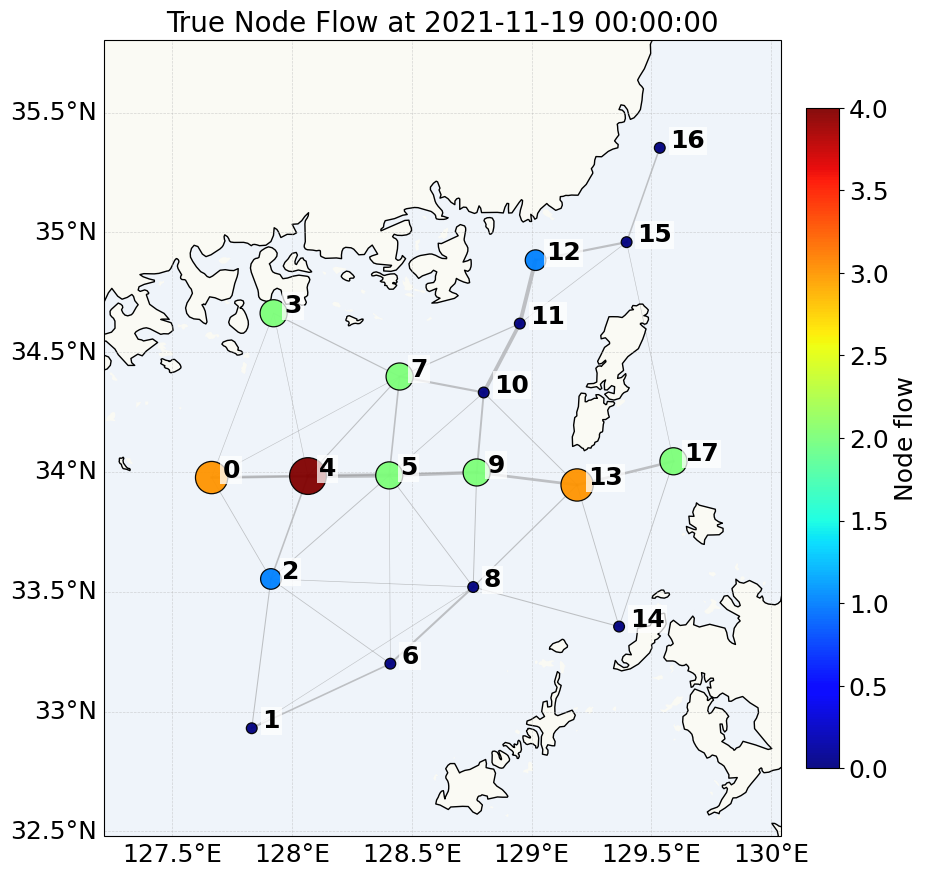

Saved figure: Graph_WaveNet/true_node_flow_with_edges_node_id.png


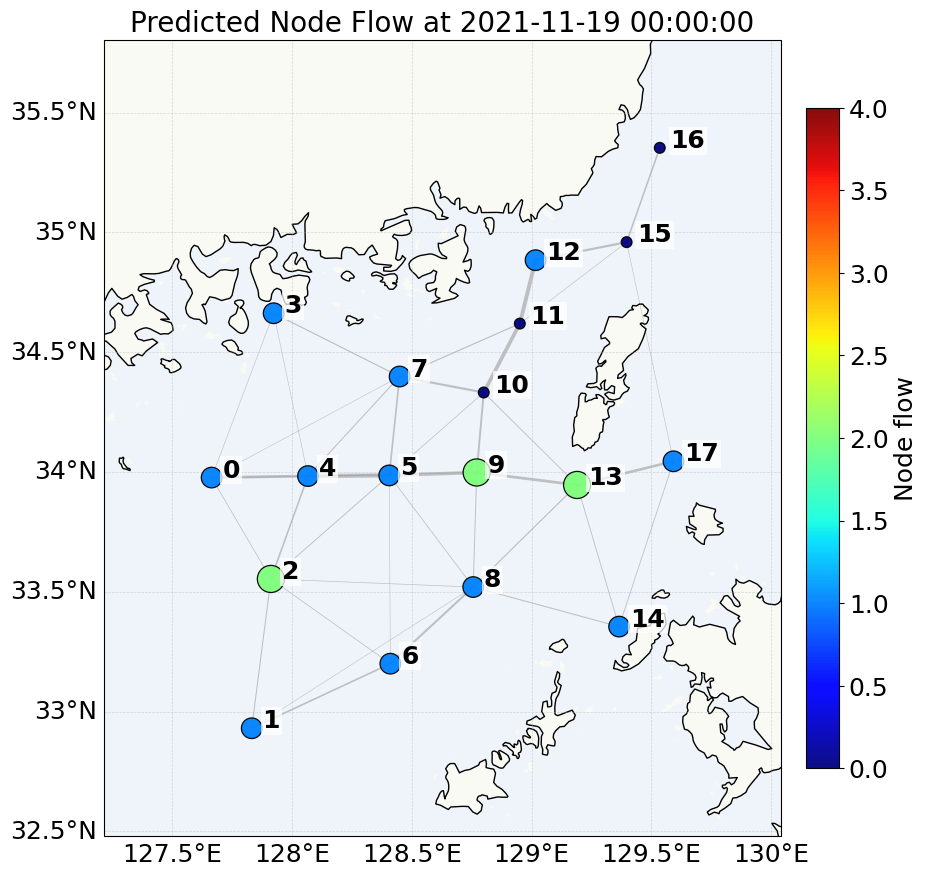

Saved figure: Graph_WaveNet/pred_node_flow_with_edges_node_id.png


In [6]:
# ============================================================
# Cell: Test Graph WaveNet and plot true/predicted node flow with Cartopy
# Only node IDs are shown, placed beside the circles
# ============================================================

# Common packages such as os, numpy, torch, nn, and F are imported in the training cell.
import matplotlib.pyplot as plt

import cartopy.crs as ccrs
import cartopy.feature as cfeature

# ============================================================
# 1) Paths and settings
# ============================================================

DATA_PATH = "GNN_flow_data/korea_strait_graph_flow_2021_k18_2h.npz"
BEST_MODEL_PATH = "Graph_WaveNet/best_model.pth"

OUT_DIR = "Graph_WaveNet"
os.makedirs(OUT_DIR, exist_ok=True)

TRUE_FIG_PATH = os.path.join(OUT_DIR, "true_node_flow_with_edges_node_id.png")
PRED_FIG_PATH = os.path.join(OUT_DIR, "pred_node_flow_with_edges_node_id.png")

# Select one test sample for visualization.
# "max_true_sum" chooses the sample with the largest observed total flow.
SAMPLE_MODE = "max_true_sum"   # or "first"

# Node marker size
MIN_MARKER_SIZE = 60
MAX_MARKER_SIZE = 700

# Edge plotting setting
EDGE_TOP_K = 45
MIN_EDGE_WIDTH = 0.4
MAX_EDGE_WIDTH = 3.0

# Text offset (in degrees)
TEXT_DX = 0.045
TEXT_DY = 0.030

# Font size settings
TITLE_FONT_SIZE = 20
NODE_TEXT_FONT_SIZE = 18
GRID_LABEL_FONT_SIZE = 18
COLORBAR_LABEL_FONT_SIZE = 18
COLORBAR_TICK_FONT_SIZE = 18

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

# ============================================================
# 2) Load graph data
# ============================================================

# Load the same graph-flow dataset used during model training.
data = np.load(DATA_PATH, allow_pickle=True)

X_node = data["X_node"].astype(np.float32)       # [samples, P, N, F]
Y_node = data["Y_node"].astype(np.float32)       # [samples, Q, N, 1]
test_idx = data["test_idx"].astype(int)

time_index = data["time_index"]
node_center_lat = data["node_center_lat"].astype(float)
node_center_lng = data["node_center_lng"].astype(float)

# Historical transition matrix
C_transition = data["C_transition"].astype(np.float32)

# Symmetric transition strength for plotting undirected graph edges
C_plot = C_transition + C_transition.T

N = len(node_center_lat)

print("X_node shape:", X_node.shape)
print("Y_node shape:", Y_node.shape)
print("Number of test samples:", len(test_idx))
print("Number of nodes:", N)

# ============================================================
# 3) Define Graph WaveNet model structure
#    Must be consistent with the Graph WaveNet training cell
# ============================================================

class GraphWaveNetGraphConv(nn.Module):
    """
    Graph convolution used in Graph WaveNet.

    Input:
        x: [B, C, N, T]
        supports: list of [N, N]

    Output:
        out: [B, C_out, N, T]
    """
    def __init__(self, in_channels, out_channels, support_len, dropout=0.1):
        super().__init__()

        self.mlp = nn.Conv2d(
            in_channels * (support_len + 1),
            out_channels,
            kernel_size=(1, 1)
        )

        self.dropout = nn.Dropout(dropout)

    def forward(self, x, supports):
        out = [x]

        for A in supports:
            x_g = torch.einsum("ij,bcjt->bcit", A, x)
            out.append(x_g)

        out = torch.cat(out, dim=1)
        out = self.mlp(out)
        out = self.dropout(out)

        return out


class GraphWaveNetBlock(nn.Module):
    """
    Graph WaveNet block:
        dilated causal temporal convolution + graph convolution + residual connection
    """
    def __init__(
        self,
        channels,
        kernel_size,
        dilation,
        support_len,
        dropout=0.1
    ):
        super().__init__()

        self.kernel_size = kernel_size
        self.dilation = dilation
        self.padding = dilation * (kernel_size - 1)

        self.filter_conv = nn.Conv2d(
            channels,
            channels,
            kernel_size=(1, kernel_size),
            dilation=(1, dilation)
        )

        self.gate_conv = nn.Conv2d(
            channels,
            channels,
            kernel_size=(1, kernel_size),
            dilation=(1, dilation)
        )

        self.graph_conv = GraphWaveNetGraphConv(
            in_channels=channels,
            out_channels=channels,
            support_len=support_len,
            dropout=dropout
        )

        self.residual_conv = nn.Conv2d(
            channels,
            channels,
            kernel_size=(1, 1)
        )

        self.bn = nn.BatchNorm2d(channels)
        self.dropout = nn.Dropout(dropout)

    def forward(self, x, supports):
        # x: [B, C, N, T]

        residual = x

        # Causal padding on temporal dimension
        x_pad = F.pad(x, (self.padding, 0, 0, 0))

        filter_out = torch.tanh(self.filter_conv(x_pad))
        gate_out = torch.sigmoid(self.gate_conv(x_pad))

        out = filter_out * gate_out
        out = self.dropout(out)

        out = self.graph_conv(out, supports)
        out = self.residual_conv(out)

        out = out + residual
        out = self.bn(out)

        return out


class GraphWaveNetModel(nn.Module):
    """
    Graph WaveNet for node-level maritime traffic flow prediction.

    Input:
        x: [B, P, N, F]

    Output:
        y_hat: [B, Q, N, 1]
    """
    def __init__(
        self,
        input_dim,
        hidden_dim,
        num_nodes,
        output_dim=1,
        q=1,
        kernel_size=3,
        dilations=None,
        adaptive_emb_dim=10,
        dropout=0.1
    ):
        super().__init__()

        if dilations is None:
            dilations = [1, 2, 4]

        self.num_nodes = num_nodes
        self.hidden_dim = hidden_dim
        self.output_dim = output_dim
        self.q = q
        self.dilations = dilations

        self.start_conv = nn.Conv2d(
            input_dim,
            hidden_dim,
            kernel_size=(1, 1)
        )

        # Adaptive adjacency matrix
        self.nodevec1 = nn.Parameter(
            torch.randn(num_nodes, adaptive_emb_dim),
            requires_grad=True
        )

        self.nodevec2 = nn.Parameter(
            torch.randn(adaptive_emb_dim, num_nodes),
            requires_grad=True
        )

        support_len = 2   # predefined adjacency + adaptive adjacency

        self.blocks = nn.ModuleList([
            GraphWaveNetBlock(
                channels=hidden_dim,
                kernel_size=kernel_size,
                dilation=d,
                support_len=support_len,
                dropout=dropout
            )
            for d in dilations
        ])

        self.decoder = nn.Sequential(
            nn.Linear(hidden_dim, hidden_dim),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim, q * output_dim)
        )

    def forward(self, x, A_norm):
        # x: [B, P, N, F]

        # [B, P, N, F] -> [B, F, N, P]
        x = x.permute(0, 3, 2, 1)

        # Initial projection
        x = self.start_conv(x)                 # [B, H, N, P]

        # Adaptive adjacency
        A_adp = F.softmax(
            F.relu(torch.mm(self.nodevec1, self.nodevec2)),
            dim=1
        )

        supports = [A_norm, A_adp]

        for block in self.blocks:
            x = block(x, supports)

        # Use the last temporal state
        h = x[:, :, :, -1]                     # [B, H, N]
        h = h.permute(0, 2, 1)                 # [B, N, H]

        out = self.decoder(h)                  # [B, N, Q]
        out = out.view(out.shape[0], out.shape[1], self.q, self.output_dim)
        out = out.permute(0, 2, 1, 3)           # [B, Q, N, 1]

        out = F.softplus(out)

        return out


# ============================================================
# 4) Load trained Graph WaveNet model
# ============================================================

checkpoint = torch.load(BEST_MODEL_PATH, map_location=device)

config = checkpoint["config"]

x_scale = checkpoint["x_scale"]
if not isinstance(x_scale, np.ndarray):
    x_scale = np.array(x_scale, dtype=np.float32)
else:
    x_scale = x_scale.astype(np.float32)

y_scale = float(checkpoint["y_scale"])

A_norm = checkpoint["A_norm"]
if not isinstance(A_norm, np.ndarray):
    A_norm = np.array(A_norm, dtype=np.float32)
else:
    A_norm = A_norm.astype(np.float32)

P = int(config["P"])
Q = int(config["Q"])
F_in = int(config["input_features"])
HIDDEN_DIM = int(config["hidden_dim"])
DROPOUT = float(config["dropout"])
KERNEL_SIZE = int(config.get("kernel_size", 3))
DILATIONS = config.get("dilations", [1, 2, 4])
ADAPTIVE_EMB_DIM = int(config.get("adaptive_emb_dim", 10))

A_tensor = torch.from_numpy(A_norm).float().to(device)

model = GraphWaveNetModel(
    input_dim=F_in,
    hidden_dim=HIDDEN_DIM,
    num_nodes=N,
    output_dim=1,
    q=Q,
    kernel_size=KERNEL_SIZE,
    dilations=DILATIONS,
    adaptive_emb_dim=ADAPTIVE_EMB_DIM,
    dropout=DROPOUT
).to(device)

model.load_state_dict(checkpoint["model_state_dict"])
model.eval()

print("Loaded best model from:", BEST_MODEL_PATH)
print("Best epoch:", checkpoint["epoch"])
print("y_scale:", y_scale)
print("x_scale:", x_scale)
print("kernel_size:", KERNEL_SIZE)
print("dilations:", DILATIONS)
print("adaptive_emb_dim:", ADAPTIVE_EMB_DIM)

# ============================================================
# 5) Select one test sample
# ============================================================

if SAMPLE_MODE == "max_true_sum":
    true_sums = Y_node[test_idx].sum(axis=(1, 2, 3))
    selected_sample_index = test_idx[np.argmax(true_sums)]
else:
    selected_sample_index = test_idx[0]

target_time_step = selected_sample_index + P
target_time = time_index[target_time_step]

print("\nSelected sample index:", selected_sample_index)
print("Target time:", target_time)

x_sample = X_node[selected_sample_index]        # [P, N, F]
y_true = Y_node[selected_sample_index]          # [Q, N, 1], already original count scale

# Normalize input only
x_sample_norm = x_sample / x_scale.reshape(1, 1, -1)
x_tensor = torch.from_numpy(x_sample_norm).float().unsqueeze(0).to(device)

with torch.no_grad():
    y_pred_norm = model(x_tensor, A_tensor)

# Prediction back to original scale
y_pred = y_pred_norm.cpu().numpy()[0] * y_scale

# True values are already original counts
y_true_ori = y_true

true_flow = y_true_ori[0, :, 0]
pred_flow = y_pred[0, :, 0]

# Use rounded integer values for visualization
true_flow_plot = np.rint(true_flow).astype(float)
pred_flow_plot = np.rint(pred_flow).astype(float)

print("\nTrue node flow:")
print(true_flow)

print("\nPredicted node flow:")
print(pred_flow)

print("\nRounded true node flow:")
print(true_flow_plot.astype(int))

print("\nRounded predicted node flow:")
print(pred_flow_plot.astype(int))

print("\nTotal true flow:", true_flow.sum())
print("Total predicted flow:", pred_flow.sum())
print("Total rounded true flow:", true_flow_plot.sum())
print("Total rounded predicted flow:", pred_flow_plot.sum())

# ============================================================
# 6) Prepare graph edges for plotting
# ============================================================

def get_top_edges(C, top_k=45):
    edges = []
    N = C.shape[0]

    for i in range(N):
        for j in range(i + 1, N):
            w = C[i, j]
            if w > 0:
                edges.append((i, j, float(w)))

    edges = sorted(edges, key=lambda x: x[2], reverse=True)

    if top_k is not None:
        edges = edges[:top_k]

    return edges


plot_edges = get_top_edges(C_plot, top_k=EDGE_TOP_K)

edge_weights = np.array([e[2] for e in plot_edges], dtype=float)

if len(edge_weights) > 0:
    edge_w_min = edge_weights.min()
    edge_w_max = edge_weights.max()
else:
    edge_w_min = 0.0
    edge_w_max = 1.0

print("\nNumber of plotted edges:", len(plot_edges))
print("Edge weight range:", edge_w_min, "to", edge_w_max)

# ============================================================
# 7) Plot function with Cartopy
# ============================================================

def plot_node_flow_cartopy_with_edges(
    values,
    node_lng,
    node_lat,
    edges,
    title,
    save_path,
    vmin=0.0,
    vmax=None
):
    values = np.asarray(values, dtype=float)

    if vmax is None:
        vmax = max(float(values.max()), 1.0)

    # Marker size based on integer values
    if vmax > vmin:
        sizes = MIN_MARKER_SIZE + (values - vmin) / (vmax - vmin) * (MAX_MARKER_SIZE - MIN_MARKER_SIZE)
    else:
        sizes = np.ones_like(values) * MIN_MARKER_SIZE

    lon_min = float(node_lng.min()) - 0.45
    lon_max = float(node_lng.max()) + 0.45
    lat_min = float(node_lat.min()) - 0.45
    lat_max = float(node_lat.max()) + 0.45

    proj = ccrs.PlateCarree()

    fig = plt.figure(figsize=(9.5, 9.5))
    ax = plt.axes(projection=proj)

    ax.set_extent(
        [lon_min, lon_max, lat_min, lat_max],
        crs=proj
    )

    # Map features
    ax.add_feature(cfeature.LAND, alpha=0.30)
    ax.add_feature(cfeature.OCEAN, alpha=0.15)
    ax.add_feature(cfeature.COASTLINE, linewidth=1.0)
    ax.add_feature(cfeature.BORDERS, linewidth=0.7, alpha=0.5)

    gl = ax.gridlines(
        draw_labels=True,
        linewidth=0.5,
        alpha=0.5,
        linestyle="--"
    )
    gl.top_labels = False
    gl.right_labels = False
    gl.xlabel_style = {"size": GRID_LABEL_FONT_SIZE}
    gl.ylabel_style = {"size": GRID_LABEL_FONT_SIZE}

    # Draw historical graph edges
    for i, j, w in edges:
        if edge_w_max > edge_w_min:
            lw = MIN_EDGE_WIDTH + (w - edge_w_min) / (edge_w_max - edge_w_min) * (MAX_EDGE_WIDTH - MIN_EDGE_WIDTH)
        else:
            lw = MIN_EDGE_WIDTH

        ax.plot(
            [node_lng[i], node_lng[j]],
            [node_lat[i], node_lat[j]],
            color="gray",
            linewidth=lw,
            alpha=0.45,
            transform=proj,
            zorder=1
        )

    # Draw nodes
    sc = ax.scatter(
        node_lng,
        node_lat,
        c=values,
        s=sizes,
        cmap="jet",
        vmin=vmin,
        vmax=vmax,
        edgecolors="black",
        linewidths=0.9,
        alpha=0.95,
        transform=proj,
        zorder=3
    )

    # Draw only node IDs beside circles
    for idx, (lon, lat) in enumerate(zip(node_lng, node_lat)):
        ax.text(
            lon + TEXT_DX,
            lat + TEXT_DY,
            f"{idx}",
            fontsize=NODE_TEXT_FONT_SIZE,
            fontweight="bold",
            ha="left",
            va="center",
            color="black",
            bbox=dict(facecolor="white", edgecolor="none", alpha=0.75, pad=1.5),
            transform=proj,
            zorder=4
        )

    cbar = plt.colorbar(sc, ax=ax, shrink=0.75, pad=0.03)
    cbar.set_label("Node flow", fontsize=COLORBAR_LABEL_FONT_SIZE)
    cbar.ax.tick_params(labelsize=COLORBAR_TICK_FONT_SIZE)

    ax.set_title(title, fontsize=TITLE_FONT_SIZE)

    plt.tight_layout()
    plt.savefig(save_path, dpi=900)
    plt.show()

    print("Saved figure:", save_path)

# ============================================================
# 8) Draw true and predicted maps
# ============================================================

common_vmax = max(
    float(true_flow_plot.max()),
    float(pred_flow_plot.max()),
    1.0
)

plot_node_flow_cartopy_with_edges(
    values=true_flow_plot,
    node_lng=node_center_lng,
    node_lat=node_center_lat,
    edges=plot_edges,
    title=f"True Node Flow at {target_time}",
    save_path=os.path.join(OUT_DIR, "true_node_flow_with_edges_node_id.png"),
    vmin=0.0,
    vmax=common_vmax
)

plot_node_flow_cartopy_with_edges(
    values=pred_flow_plot,
    node_lng=node_center_lng,
    node_lat=node_center_lat,
    edges=plot_edges,
    title=f"Predicted Node Flow at {target_time}",
    save_path=os.path.join(OUT_DIR, "pred_node_flow_with_edges_node_id.png"),
    vmin=0.0,
    vmax=common_vmax
)